Connected to Python 3.12.10

In [ ]:
import os
import random
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
#  list number of files
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")


def get_random_image(directory, class_name):
  class_directory = Path(directory) / class_name
  if not class_directory.is_dir():
    raise FileNotFoundError(f"Class directory not found: {class_directory}")

  image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
  image_paths = [
    path for path in class_directory.iterdir()
    if path.is_file() and path.suffix.lower() in image_extensions
  ]
  if not image_paths:
    raise FileNotFoundError(f"No image files found in: {class_directory}")

  with Image.open(random.choice(image_paths)) as image:
    image = image.copy()

  plt.imshow(image)
  plt.title(class_name)
  plt.axis('off')
  plt.show()
  return image

There are 2 directories and 0 images in 'pizza_steak'.
There are 2 directories and 0 images in 'pizza_steak\test'.
There are 0 directories and 250 images in 'pizza_steak\test\pizza'.
There are 0 directories and 250 images in 'pizza_steak\test\steak'.
There are 2 directories and 0 images in 'pizza_steak\train'.
There are 0 directories and 750 images in 'pizza_steak\train\pizza'.
There are 0 directories and 750 images in 'pizza_steak\train\steak'.


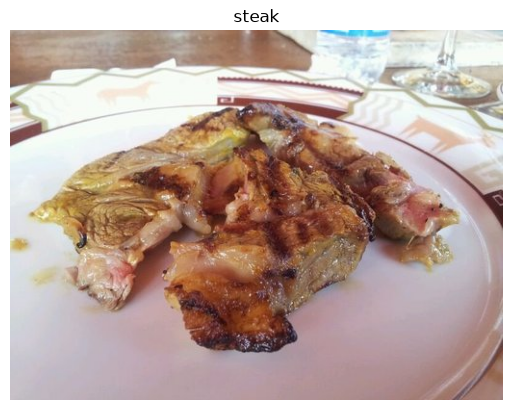

In [ ]:
img = get_random_image('C:/Interview Process/python_tf/pizza_steak/test', 'steak')
image = np.array(img, dtype=np.float32) / 255.0

In [ ]:
import tensorflow as tf

tf.constant(image)

<tf.Tensor: shape=(384, 512, 3), dtype=float32, numpy=
array([[[0.7137255 , 0.6509804 , 0.6       ],
        [0.70980394, 0.64705884, 0.59607846],
        [0.7019608 , 0.6392157 , 0.5882353 ],
        ...,
        [0.70980394, 0.7921569 , 0.8117647 ],
        [0.69803923, 0.7921569 , 0.80784315],
        [0.69411767, 0.7882353 , 0.8039216 ]],

       [[0.6901961 , 0.61960787, 0.57254905],
        [0.68235296, 0.61960787, 0.5686275 ],
        [0.6745098 , 0.6117647 , 0.56078434],
        ...,
        [0.7529412 , 0.8352941 , 0.85490197],
        [0.7529412 , 0.8352941 , 0.85490197],
        [0.7529412 , 0.8352941 , 0.85490197]],

       [[0.6745098 , 0.6       , 0.54509807],
        [0.6666667 , 0.59607846, 0.5411765 ],
        [0.65882355, 0.5882353 , 0.53333336],
        ...,
        [0.79607844, 0.87058824, 0.8862745 ],
        [0.8       , 0.8745098 , 0.8901961 ],
        [0.8039216 , 0.8784314 , 0.89411765]],

       ...,

       [[0.78039217, 0.7529412 , 0.78039217],
        [0.78

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale = 1./255)

#  Import data from directories and turn into batches
train_dir = 'C:/Interview Process/python_tf/pizza_steak/train'
test_dir = 'C:/Interview Process/python_tf/pizza_steak/test'

train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode='binary',
                                               seed=42)
valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode='binary',
                                               seed=42)

model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                          kernel_size=3,
                          activation='relu',
                          input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding='valid'),
    tf.keras.layers.Conv2D(10,3,activation='relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

#  compile our CNN
model_1.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])
# 04ms/step - accuracy: 1.0000 - loss: 1.2797e-08 - val_accuracy: 0.5000 - val_loss: 20.4517

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [ ]:
# Create ImageDataGenerator training instance with data augmentation
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=20, # rotate the image slightly between 0 and 20 degrees (note: this is an int not a float)
                                             shear_range=0.2, # shear the image
                                             zoom_range=0.2, # zoom into the image
                                             width_shift_range=0.2, # shift the image width ways
                                             height_shift_range=0.2, # shift the image height ways
                                             horizontal_flip=True) # flip the image on the horizontal axis

# Create ImageDataGenerator training instance without data augmentation
train_datagen = ImageDataGenerator(rescale=1/255.) 

# Create ImageDataGenerator test instance without data augmentation
test_datagen = ImageDataGenerator(rescale=1/255.)

# Import data and augment it from training directory
print("Augmented training images:")
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224, 224),
                                                                   batch_size=32,
                                                                   class_mode='binary',
                                                                   shuffle=False) # Don't shuffle for demonstration purposes, usually a good thing to shuffle

# Create non-augmented data batches
print("Non-augmented training images:")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode='binary',
                                               shuffle=False) # Don't shuffle for demonstration purposes

print("Unchanged test images:")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(224, 224),
                                             batch_size=32,
                                             class_mode='binary')

Augmented training images:
Found 1500 images belonging to 2 classes.
Non-augmented training images:
Found 1500 images belonging to 2 classes.
Unchanged test images:
Found 500 images belonging to 2 classes.


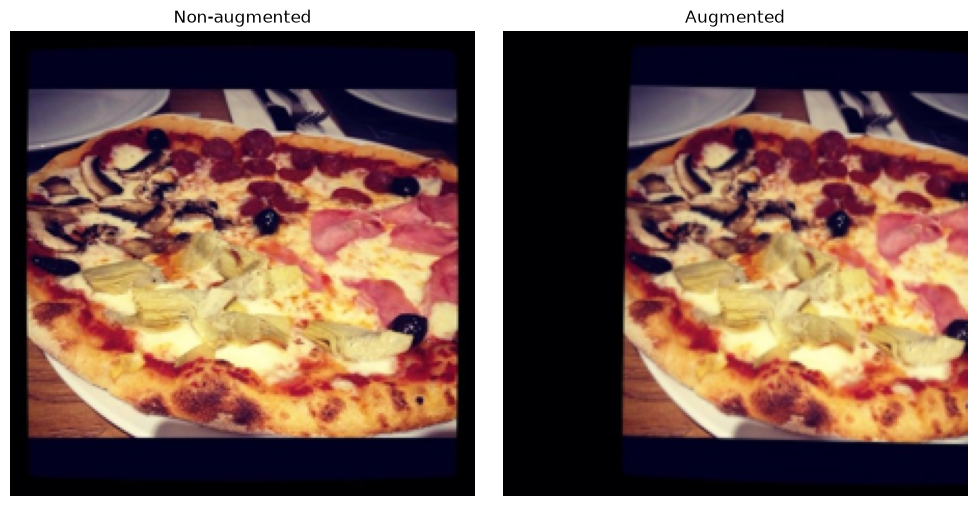

In [ ]:
# Display the same randomly selected training image with and without augmentation.
random_image_path = random.choice(train_data.filepaths)
with Image.open(random_image_path) as source_image:
  source_image = source_image.convert('RGB').resize((224, 224))

# Apply the transform before rescaling; standardize() applies rescale=1/255.
original_array = np.asarray(source_image, dtype=np.float32)
augmented_array = train_datagen_augmented.random_transform(original_array.copy())
augmented_array = train_datagen_augmented.standardize(augmented_array)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_array / 255.0)
axes[0].set_title('Non-augmented')
axes[0].axis('off')
axes[1].imshow(np.clip(augmented_array, 0, 1))
axes[1].set_title('Augmented')
axes[1].axis('off')
plt.tight_layout()
plt.show()

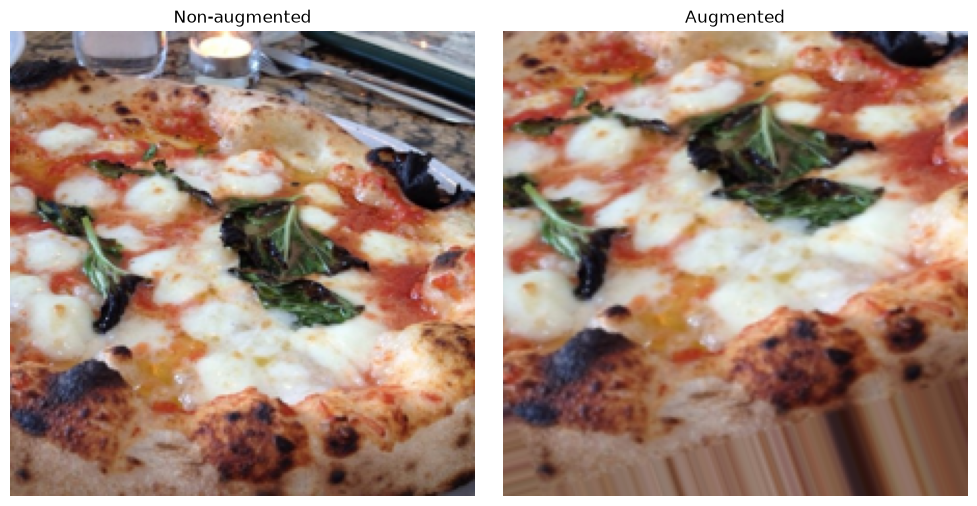

In [ ]:
# Display the same randomly selected training image with and without augmentation.
random_image_path = random.choice(train_data.filepaths)
with Image.open(random_image_path) as source_image:
  source_image = source_image.convert('RGB').resize((224, 224))

# Apply the transform before rescaling; standardize() applies rescale=1/255.
original_array = np.asarray(source_image, dtype=np.float32)
augmented_array = train_datagen_augmented.random_transform(original_array.copy())
augmented_array = train_datagen_augmented.standardize(augmented_array)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_array / 255.0)
axes[0].set_title('Non-augmented')
axes[0].axis('off')
axes[1].imshow(np.clip(augmented_array, 0, 1))
axes[1].set_title('Augmented')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Create the model (same as model_5)
model_6 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
  MaxPool2D(pool_size=2), # reduce number of features by half
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(1, activation='sigmoid')
])

# Compile the model
model_6.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

NameError: name 'Sequential' is not defined

In [ ]:
# Make the creating of our model a little easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential

In [ ]:
# Create the model (same as model_5)
model_6 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
  MaxPool2D(pool_size=2), # reduce number of features by half
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(1, activation='sigmoid')
])

# Compile the model
model_6.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

In [ ]:
# Fit the model
history_6 = model_6.fit(train_data_augmented, # changed to augmented training data
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 434ms/step - accuracy: 0.4827 - loss: 0.7127 - val_accuracy: 0.5440 - val_loss: 0.6826
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 442ms/step - accuracy: 0.4720 - loss: 0.7227 - val_accuracy: 0.7820 - val_loss: 0.6705
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 438ms/step - accuracy: 0.6120 - loss: 0.6792 - val_accuracy: 0.6580 - val_loss: 0.6489
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 440ms/step - accuracy: 0.6167 - loss: 0.6817 - val_accuracy: 0.7200 - val_loss: 0.6136
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 456ms/step - accuracy: 0.6480 - loss: 0.6434 - val_accuracy: 0.8000 - val_loss: 0.5162


In [ ]:
plot_loss_curves(history_6)

NameError: name 'plot_loss_curves' is not defined

In [ ]:
# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """ 
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

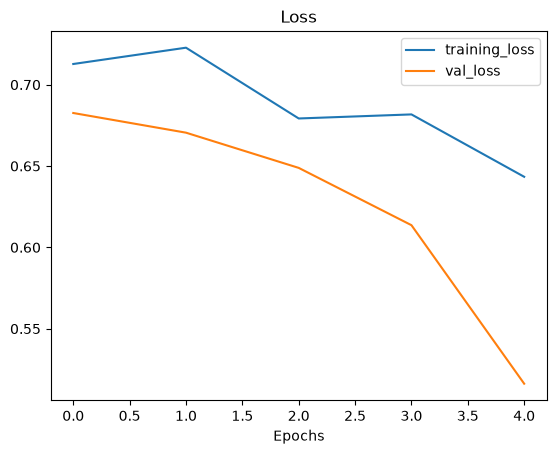

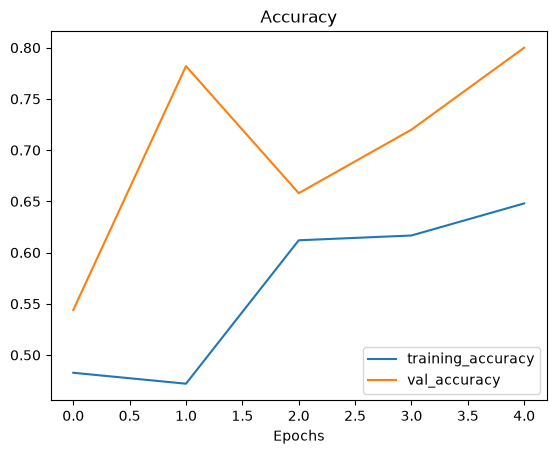

In [ ]:
plot_loss_curves(history_6)

In [ ]:
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode='binary',
                                               shuffle=True)

Found 1500 images belonging to 2 classes.


In [ ]:
train_data_shuffled = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode='binary',
                                               shuffle=True)

Found 1500 images belonging to 2 classes.


In [ ]:
model_7 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)),
  MaxPool2D(pool_size=2), # reduce number of features by half
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(1, activation='sigmoid')
])

In [ ]:
# Compile the model
model_7.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

history_7 = model_7.fit(train_data_shuffled, # changed to augmented training data
                        epochs=5,
                        steps_per_epoch=len(train_data_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - accuracy: 0.6540 - loss: 0.5970 - val_accuracy: 0.7980 - val_loss: 0.4518
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.7660 - loss: 0.4939 - val_accuracy: 0.8220 - val_loss: 0.4214
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.7960 - loss: 0.4512 - val_accuracy: 0.8380 - val_loss: 0.3895
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step - accuracy: 0.8227 - loss: 0.4119 - val_accuracy: 0.8640 - val_loss: 0.3708
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 166ms/step - accuracy: 0.8387 - loss: 0.3740 - val_accuracy: 0.8680 - val_loss: 0.3309


In [ ]:
class_names = np.array(['pizza', 'steak'])

# We can index the predicted class by rounding the prediction probability
pred_class = class_names[int(tf.round(pred)[0][0])]
pred_class

NameError: name 'pred' is not defined

In [ ]:
def get_image(path):
  image_path = Path(path)

  if image_path.is_file():
    with Image.open(image_path) as image:
      return image

  if image_path.is_dir():
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    image_paths = [
      p for p in image_path.iterdir()
      if p.is_file() and p.suffix.lower() in image_extensions
    ]
    if not image_paths:
      raise FileNotFoundError(f"No image files found in: {image_path}")

    with Image.open(random.choice(image_paths)) as image:
      return image

  raise FileNotFoundError(f"Image file or directory not found: {image_path}")

img_for_pred = get_image(r'C:/Interview Process/python_tf/03-steak.jpeg')

print(np.asarray(img_for_pred).shape)

AssertionError: 

In [ ]:
def get_image(path):
  image_path = Path(path)

  if image_path.is_file():
    with Image.open(image_path) as image:
      return image

  if image_path.is_dir():
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    image_paths = [
      p for p in image_path.iterdir()
      if p.is_file() and p.suffix.lower() in image_extensions
    ]
    if not image_paths:
      raise FileNotFoundError(f"No image files found in: {image_path}")

    with Image.open(random.choice(image_paths)) as image:
      return image

  raise FileNotFoundError(f"Image file or directory not found: {image_path}")

img_for_pred = get_image(r'C:/Interview Process/python_tf/03-steak.jpeg')

print(np.asarray(img_for_pred))

AssertionError: 

In [ ]:
class_names = np.array(['pizza', 'steak'])

# Load an image and prepare it for the model.
def get_image(path):
  image_path = Path(path)

  if image_path.is_file():
    with Image.open(image_path) as image:
      return image.convert('RGB')

  if image_path.is_dir():
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    image_paths = [
      p for p in image_path.iterdir()
      if p.is_file() and p.suffix.lower() in image_extensions
    ]
    if not image_paths:
      raise FileNotFoundError(f"No image files found in: {image_path}")

    with Image.open(random.choice(image_paths)) as image:
      return image.convert('RGB')

  raise FileNotFoundError(f"Image file or directory not found: {image_path}")


img_for_pred = get_image(r'C:/Interview Process/python_tf/03-steak.jpeg')

np.asarray(img_for_pred)

array([[[162, 158, 149],
        [163, 159, 150],
        [166, 162, 153],
        ...,
        [136,  17,  23],
        [140,  21,  27],
        [140,  21,  27]],

       [[164, 160, 151],
        [164, 160, 151],
        [164, 160, 151],
        ...,
        [133,  14,  20],
        [134,  15,  21],
        [137,  18,  24]],

       [[166, 162, 153],
        [165, 161, 152],
        [163, 159, 150],
        ...,
        [136,  17,  23],
        [134,  15,  21],
        [136,  17,  23]],

       ...,

       [[154, 132, 111],
        [142, 121, 100],
        [101,  80,  59],
        ...,
        [164, 155, 148],
        [152, 141, 135],
        [140, 129, 123]],

       [[141, 119,  96],
        [138, 118,  94],
        [106,  85,  64],
        ...,
        [158, 147, 141],
        [142, 131, 125],
        [138, 127, 121]],

       [[148, 126, 102],
        [148, 128, 103],
        [114,  93,  72],
        ...,
        [153, 142, 136],
        [138, 127, 121],
        [143, 132, 126]]

In [ ]:
class_names = np.array(['pizza', 'steak'])

# Load an image and prepare it for the model.
def get_image(path):
  image_path = Path(path)

  if image_path.is_file():
    with Image.open(image_path) as image:
      return image.convert('RGB')

  if image_path.is_dir():
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    image_paths = [
      p for p in image_path.iterdir()
      if p.is_file() and p.suffix.lower() in image_extensions
    ]
    if not image_paths:
      raise FileNotFoundError(f"No image files found in: {image_path}")

    with Image.open(random.choice(image_paths)) as image:
      return image.convert('RGB')

  raise FileNotFoundError(f"Image file or directory not found: {image_path}")


img_for_pred = get_image(r'C:/Interview Process/python_tf/03-steak.jpeg')

np.asarray(img_for_pred).shape

(4032, 3024, 3)

In [ ]:
class_names = np.array(['pizza', 'steak'])

# Load an image and prepare it for the model.
def get_image(path):
  image_path = Path(path)

  if image_path.is_file():
    with Image.open(image_path) as image:
      return image.convert('RGB')

  if image_path.is_dir():
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    image_paths = [
      p for p in image_path.iterdir()
      if p.is_file() and p.suffix.lower() in image_extensions
    ]
    if not image_paths:
      raise FileNotFoundError(f"No image files found in: {image_path}")

    with Image.open(random.choice(image_paths)) as image:
      return image.convert('RGB')

  raise FileNotFoundError(f"Image file or directory not found: {image_path}")


img_for_pred = get_image(r'C:/Interview Process/python_tf/03-steak.jpeg')

np.asarray(img_for_pred).shape

# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """
  # Read in target file (an image)
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor & ensure 3 colour channels 
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [ ]:
img_for_pred = load_and_prep_image(img_for_pred)

img_for_pred

ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type int).

In [ ]:
class_names = np.array(['pizza', 'steak'])

# Load an image and prepare it for the model.
def get_image(path):
  image_path = Path(path)

  if image_path.is_file():
    with Image.open(image_path) as image:
      return image.convert('RGB')

  if image_path.is_dir():
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    image_paths = [
      p for p in image_path.iterdir()
      if p.is_file() and p.suffix.lower() in image_extensions
    ]
    if not image_paths:
      raise FileNotFoundError(f"No image files found in: {image_path}")

    with Image.open(random.choice(image_paths)) as image:
      return image.convert('RGB')

  raise FileNotFoundError(f"Image file or directory not found: {image_path}")


img_for_pred = get_image(r'C:/Interview Process/python_tf/03-steak.jpeg')

np.asarray(img_for_pred).shape

# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(img, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """
  # Decode the read file into a tensor & ensure 3 colour channels 
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [ ]:
img_for_pred = load_and_prep_image(img_for_pred)

img_for_pred

ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type int).

In [ ]:
class_names = np.array(['pizza', 'steak'])

# Load an image and prepare it for the model.
def get_image(path):
  image_path = Path(path)

  if image_path.is_file():
    with Image.open(image_path) as image:
      return image.convert('RGB')

  if image_path.is_dir():
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    image_paths = [
      p for p in image_path.iterdir()
      if p.is_file() and p.suffix.lower() in image_extensions
    ]
    if not image_paths:
      raise FileNotFoundError(f"No image files found in: {image_path}")

    with Image.open(random.choice(image_paths)) as image:
      return image.convert('RGB')

  raise FileNotFoundError(f"Image file or directory not found: {image_path}")


img_for_pred = get_image(r'C:/Interview Process/python_tf/03-steak.jpeg')

np.asarray(img_for_pred).shape

# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(img, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """


  # Decode the read file into a tensor & ensure 3 colour channels 
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  if isinstance(img, np.ndarray):
    # get_image() already returns a decoded PIL image; accept its NumPy array too.
    img = tf.convert_to_tensor(img.tolist(), dtype=tf.float32)
    if img.shape.rank == 2:
      img = tf.expand_dims(img, axis=-1)
    if img.shape[-1] == 1:
      img = tf.image.grayscale_to_rgb(img)
    elif img.shape[-1] == 4:
      img = img[..., :3]
  else:
    img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [ ]:
img_for_pred = load_and_prep_image(img_for_pred)

img_for_pred

ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type int).

In [ ]:
class_names = np.array(['pizza', 'steak'])

# Load an image and prepare it for the model.
def get_image(path):
  image_path = Path(path)

  if image_path.is_file():
    with Image.open(image_path) as image:
      return image.convert('RGB')

  if image_path.is_dir():
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    image_paths = [
      p for p in image_path.iterdir()
      if p.is_file() and p.suffix.lower() in image_extensions
    ]
    if not image_paths:
      raise FileNotFoundError(f"No image files found in: {image_path}")

    with Image.open(random.choice(image_paths)) as image:
      return image.convert('RGB')

  raise FileNotFoundError(f"Image file or directory not found: {image_path}")


img_for_pred = get_image(r'C:/Interview Process/python_tf/03-steak.jpeg')

np.asarray(img_for_pred).shape

# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(img, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """


  # Decode the read file into a tensor & ensure 3 colour channels 
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  if isinstance(img, np.ndarray):
    # get_image() already returns a decoded PIL image; accept its NumPy array too.
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    if img.shape.rank == 2:
      img = tf.expand_dims(img, axis=-1)
    if img.shape[-1] == 1:
      img = tf.image.grayscale_to_rgb(img)
    elif img.shape[-1] == 4:
      img = img[..., :3]
  else:
    img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [ ]:
img_for_pred = load_and_prep_image(img_for_pred)

img_for_pred

ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type int).

In [ ]:
class_names = np.array(['pizza', 'steak'])

# Load an image and prepare it for the model.
def get_image(path):
  image_path = Path(path)

  if image_path.is_file():
    with Image.open(image_path) as image:
      return image.convert('RGB')

  if image_path.is_dir():
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    image_paths = [
      p for p in image_path.iterdir()
      if p.is_file() and p.suffix.lower() in image_extensions
    ]
    if not image_paths:
      raise FileNotFoundError(f"No image files found in: {image_path}")

    with Image.open(random.choice(image_paths)) as image:
      return image.convert('RGB')

  raise FileNotFoundError(f"Image file or directory not found: {image_path}")


img_for_pred = get_image(r'C:/Interview Process/python_tf/03-steak.jpeg')

np.asarray(img_for_pred).shape

# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(img, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """


  # Decode the read file into a tensor & ensure 3 colour channels 
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  if isinstance(img, Image.Image):
    img = np.asarray(img)

  if isinstance(img, np.ndarray):
    # get_image() already returns a decoded PIL image; accept its NumPy array too.
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    if img.shape.rank == 2:
      img = tf.expand_dims(img, axis=-1)
    if img.shape[-1] == 1:
      img = tf.image.grayscale_to_rgb(img)
    elif img.shape[-1] == 4:
      img = img[..., :3]
  else:
    img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [ ]:
img_for_pred = load_and_prep_image(img_for_pred)

img_for_pred

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.6406863 , 0.625     , 0.58186275],
        [0.65931374, 0.62990195, 0.59166664],
        [0.6357843 , 0.60833335, 0.56911767],
        ...,
        [0.5230392 , 0.05245098, 0.09166667],
        [0.5004902 , 0.04166667, 0.07696079],
        [0.53186274, 0.07696079, 0.1122549 ]],

       [[0.6632353 , 0.64754903, 0.6122549 ],
        [0.6387255 , 0.6230392 , 0.57990193],
        [0.6607843 , 0.62941176, 0.5862745 ],
        ...,
        [0.5352941 , 0.06764706, 0.09411765],
        [0.53186274, 0.06127451, 0.1004902 ],
        [0.5254902 , 0.05490196, 0.09411765]],

       [[0.65392154, 0.6382353 , 0.59117645],
        [0.64362746, 0.6122549 , 0.56911767],
        [0.65931374, 0.6279412 , 0.58480394],
        ...,
        [0.53382355, 0.06715687, 0.08480392],
        [0.53382355, 0.06617647, 0.10343137],
        [0.525     , 0.05441177, 0.09362745]],

       ...,

       [[0.49656862, 0.4254902 , 0.31813726],
        [0.05

In [ ]:
img_for_pred.shape

TensorShape([224, 224, 3])

In [ ]:
model_7.predict(img_for_pred)

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 224, 3), dtype=float32) with name 'keras_tensor_31' and path ''. Expected shape (None, 224, 224, 3), but input has incompatible shape (32, 224, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 224, 3), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
model_7.predict(tf.expand_dims(img_for_pred, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


array([[0.6954851]], dtype=float32)

In [ ]:
pred = model_7.predict(tf.expand_dims(img_for_pred, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [ ]:
pred_class = class_names(int(tf.round(pred)))

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [ ]:
pred = model_7.predict(tf.expand_dims(img_for_pred, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [ ]:
pred_class = class_names(int(tf.round(pred)))

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [ ]:
pred_class = class_names[int(tf.round(pred))]

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [ ]:
pred = model_7.predict(tf.expand_dims(img_for_pred, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [ ]:
pred_class = class_names[int(tf.round(pred))]

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [ ]:
class_names
pred
pred_class = class_names[int(tf.round(pred))]

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [ ]:
class_names
pred
# pred_class = class_names[int(tf.round(pred))]

array([[0.6954851]], dtype=float32)

In [ ]:
class_names = np.array(['pizza', 'steak'])

# Load an image and prepare it for the model.
def get_image(path):
  image_path = Path(path)

  if image_path.is_file():
    with Image.open(image_path) as image:
      return image.convert('RGB')

  if image_path.is_dir():
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    image_paths = [
      p for p in image_path.iterdir()
      if p.is_file() and p.suffix.lower() in image_extensions
    ]
    if not image_paths:
      raise FileNotFoundError(f"No image files found in: {image_path}")

    with Image.open(random.choice(image_paths)) as image:
      return image.convert('RGB')

  raise FileNotFoundError(f"Image file or directory not found: {image_path}")


img_for_pred = get_image(r'C:/Interview Process/python_tf/03-steak.jpeg')

np.asarray(img_for_pred).shape

# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(img, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """


  # Decode the read file into a tensor & ensure 3 colour channels 
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  if isinstance(img, Image.Image):
    img = np.asarray(img)

  if isinstance(img, np.ndarray):
    # get_image() already returns a decoded PIL image; accept its NumPy array too.
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    if img.shape.rank == 2:
      img = tf.expand_dims(img, axis=-1)
    if img.shape[-1] == 1:
      img = tf.image.grayscale_to_rgb(img)
    elif img.shape[-1] == 4:
      img = img[..., :3]
  else:
    img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [ ]:
class_names
pred
# pred_class = class_names[int(tf.round(pred))]

array([[0.6954851]], dtype=float32)

In [ ]:
class_names[1]
pred
# pred_class = class_names[int(tf.round(pred))]

array([[0.6954851]], dtype=float32)

In [ ]:
class_names[1]
pred
# pred_class = class_names[int(tf.round(pred))]

array([[0.6954851]], dtype=float32)

In [ ]:
class_names = np.array(['pizza', 'steak'])

# Load an image and prepare it for the model.
def get_image(path):
  image_path = Path(path)

  if image_path.is_file():
    with Image.open(image_path) as image:
      return image.convert('RGB')

  if image_path.is_dir():
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    image_paths = [
      p for p in image_path.iterdir()
      if p.is_file() and p.suffix.lower() in image_extensions
    ]
    if not image_paths:
      raise FileNotFoundError(f"No image files found in: {image_path}")

    with Image.open(random.choice(image_paths)) as image:
      return image.convert('RGB')

  raise FileNotFoundError(f"Image file or directory not found: {image_path}")


img_for_pred = get_image(r'C:/Interview Process/python_tf/03-steak.jpeg')

np.asarray(img_for_pred).shape

# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(img, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """


  # Decode the read file into a tensor & ensure 3 colour channels 
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  if isinstance(img, Image.Image):
    img = np.asarray(img)

  if isinstance(img, np.ndarray):
    # get_image() already returns a decoded PIL image; accept its NumPy array too.
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    if img.shape.rank == 2:
      img = tf.expand_dims(img, axis=-1)
    if img.shape[-1] == 1:
      img = tf.image.grayscale_to_rgb(img)
    elif img.shape[-1] == 4:
      img = img[..., :3]
  else:
    img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [ ]:
class_names[1]
pred
# pred_class = class_names[int(tf.round(pred))]

array([[0.6954851]], dtype=float32)

In [ ]:
class_names[1]
# pred
# pred_class = class_names[int(tf.round(pred))]

np.str_('steak')

In [ ]:
class_names[1]
# pred
# pred_class = class_names[int(tf.round(pred))]

np.str_('steak')

In [ ]:
class_names[1]
# pred
# pred_class = class_names[int(tf.round(pred))]

np.str_('steak')

In [ ]:
class_names = ['pizza', 'steak']

# Load an image and prepare it for the model.
def get_image(path):
  image_path = Path(path)

  if image_path.is_file():
    with Image.open(image_path) as image:
      return image.convert('RGB')

  if image_path.is_dir():
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    image_paths = [
      p for p in image_path.iterdir()
      if p.is_file() and p.suffix.lower() in image_extensions
    ]
    if not image_paths:
      raise FileNotFoundError(f"No image files found in: {image_path}")

    with Image.open(random.choice(image_paths)) as image:
      return image.convert('RGB')

  raise FileNotFoundError(f"Image file or directory not found: {image_path}")


img_for_pred = get_image(r'C:/Interview Process/python_tf/03-steak.jpeg')

np.asarray(img_for_pred).shape

# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(img, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """


  # Decode the read file into a tensor & ensure 3 colour channels 
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  if isinstance(img, Image.Image):
    img = np.asarray(img)

  if isinstance(img, np.ndarray):
    # get_image() already returns a decoded PIL image; accept its NumPy array too.
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    if img.shape.rank == 2:
      img = tf.expand_dims(img, axis=-1)
    if img.shape[-1] == 1:
      img = tf.image.grayscale_to_rgb(img)
    elif img.shape[-1] == 4:
      img = img[..., :3]
  else:
    img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [ ]:
class_names[1]
# pred
# pred_class = class_names[int(tf.round(pred))]

'steak'

In [ ]:
class_names[1]
# pred
pred_class = class_names[int(tf.round(pred))]

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [ ]:
class_names[1]
# pred
pred_class = class_names[int(pred[0][0] >= 0.5)]

In [ ]:
pred_class = class_names[int(pred[0][0] >= 0.5)]

In [ ]:
pred_class = class_names[int(pred[0][0] >= 0.5)]
pred_class

'steak'

In [ ]:
class_names = ['pizza', 'steak']

# Load an image and prepare it for the model.
def get_image(path):
  image_path = Path(path)

  if image_path.is_file():
    with Image.open(image_path) as image:
      return image.convert('RGB')

  if image_path.is_dir():
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
    image_paths = [
      p for p in image_path.iterdir()
      if p.is_file() and p.suffix.lower() in image_extensions
    ]
    if not image_paths:
      raise FileNotFoundError(f"No image files found in: {image_path}")

    with Image.open(random.choice(image_paths)) as image:
      return image.convert('RGB')

  raise FileNotFoundError(f"Image file or directory not found: {image_path}")


img_for_pred = get_image(r'C:/Interview Process/python_tf/pizza.jpg')

np.asarray(img_for_pred).shape

# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(img, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """


  # Decode the read file into a tensor & ensure 3 colour channels 
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  if isinstance(img, Image.Image):
    img = np.asarray(img)

  if isinstance(img, np.ndarray):
    # get_image() already returns a decoded PIL image; accept its NumPy array too.
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    if img.shape.rank == 2:
      img = tf.expand_dims(img, axis=-1)
    if img.shape[-1] == 1:
      img = tf.image.grayscale_to_rgb(img)
    elif img.shape[-1] == 4:
      img = img[..., :3]
  else:
    img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [ ]:
img_for_pred = load_and_prep_image(img_for_pred)

img_for_pred

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[4.9745649e-01, 3.2800746e-01, 1.9383377e-01],
        [4.7087207e-01, 3.2577404e-01, 2.1478716e-01],
        [4.3136629e-01, 2.7540642e-01, 1.7320178e-01],
        ...,
        [8.2352944e-02, 3.9215689e-03, 1.1677171e-02],
        [8.6274512e-02, 0.0000000e+00, 7.8431377e-03],
        [9.4117649e-02, 1.1764706e-02, 7.8431377e-03]],

       [[5.3484267e-01, 3.6621523e-01, 2.3288192e-01],
        [4.4933596e-01, 2.8836405e-01, 1.6287389e-01],
        [5.0654763e-01, 3.3035588e-01, 2.0096163e-01],
        ...,
        [8.2352944e-02, 3.9215689e-03, 7.8431377e-03],
        [8.6274512e-02, 0.0000000e+00, 7.8431377e-03],
        [9.4117649e-02, 1.1764706e-02, 7.8431377e-03]],

       [[5.2675700e-01, 3.5981017e-01, 2.3431997e-01],
        [5.1734447e-01, 3.4168047e-01, 2.0902987e-01],
        [5.7641059e-01, 3.8770634e-01, 2.3840286e-01],
        ...,
        [8.2352944e-02, 3.9215689e-03, 7.8431377e-03],
        [8.6712182e-02

In [ ]:
img_for_pred.shape

TensorShape([224, 224, 3])

In [ ]:
pred = model_7.predict(tf.expand_dims(img_for_pred, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [ ]:
pred_class = class_names[int(pred[0][0] >= 0.5)]
pred_class

'pizza'